# Part 1 Taxi: Statistics, EDA, and Visualizations

## NYC Yellow Taxi Analysis — January 2023

This third notebook performs some statistical analysis and exploratory data analysis (EDA) on the curated NYC Yellow Taxi dataset.

### Notebook Structure

1. Data Loading
2. Required Groupby Metrics
3. Window-Style Metrics
4. Exploratory Data Analysis (EDA)
5. Visualizations
6. Summary of Findings

## -> Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 200)

sns.set_theme(style="whitegrid")

In [2]:
curated_path = "../data/curated/part1_taxi_curated.parquet"
df = pd.read_parquet(curated_path)

print("Curated dataset shape:", df.shape)
df.head()

Curated dataset shape: (2884396, 23)


,PULocationID,DOLocationID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,PU_borough,PU_zone,DO_borough,DO_zone,pickup_date,pickup_hour,weekday,week_of_year,trip_duration_min,speed_mph,fare_per_mile,tip_rate,distance_bucket
0,161,141,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,9.3,0.00,14.30,2,Manhattan,Midtown Center,Manhattan,Lenox Hill West,2023-01-01,0,Sun,52,8.433333,6.901186,9.587629,0.000000,"[0,1)"
1,43,237,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,7.9,4.00,16.90,1,Manhattan,Central Park,Manhattan,Upper East Side South,2023-01-01,0,Sun,52,6.316667,10.448549,7.181818,0.236686,"[1,3)"
2,48,238,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,14.9,15.00,34.90,1,Manhattan,Clinton East,Manhattan,Upper West Side North,2023-01-01,0,Sun,52,12.750000,11.811765,5.936255,0.429799,"[1,3)"
3,107,79,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,11.4,3.28,19.68,1,Manhattan,Gramercy,Manhattan,East Village,2023-01-01,0,Sun,52,10.833333,7.920000,7.972028,0.166667,"[1,3)"
4,161,137,2023-01-01 00:50:34,2023-01-01 01:02:52,1.0,1.84,12.8,10.00,27.80,1,Manhattan,Midtown Center,Manhattan,Kips Bay,2023-01-01,0,Sun,52,12.300000,8.975610,6.956522,0.359712,"[1,3)"


In [3]:
raw_path = "../data/raw/tlc/yellow_tripdata_2023-01.parquet"
raw_df = pd.read_parquet(raw_path)

print("Raw dataset shape:", raw_df.shape)
raw_df.head()

Raw dataset shape: (3066766, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [4]:
print(df.info())
print("\nMissing values in curated dataset:")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\nUnique boroughs:")
print(sorted(df["PU_borough"].dropna().unique()))

print("\nUnique weekdays:")
print(df["weekday"].dropna().unique())

print("\nUnique distance buckets:")
print(df["distance_bucket"].dropna().unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2884396 entries, 0 to 2884395
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   PULocationID           int64         
 1   DOLocationID           int64         
 2   tpep_pickup_datetime   datetime64[us]
 3   tpep_dropoff_datetime  datetime64[us]
 4   passenger_count        float64       
 5   trip_distance          float64       
 6   fare_amount            float64       
 7   tip_amount             float64       
 8   total_amount           float64       
 9   payment_type           int64         
 10  PU_borough             object        
 11  PU_zone                object        
 12  DO_borough             object        
 13  DO_zone                object        
 14  pickup_date            object        
 15  pickup_hour            int32         
 16  weekday                category      
 17  week_of_year           int64         
 18  trip_duration_min     

## A. Required Groupby Metrics

1. Daily trip counts grouped by PU_borough and pickup_date.
2. Mean and median of fare_amount and trip_distance grouped by PU_borough and weekday.
3. For each pickup_hour, the proportion of trips by payment_type.
4. Mean tip_rate grouped by distance_bucket.

#### -> Daily trip counts

In [5]:
daily_trip_counts = (
    df.groupby(["PU_borough", "pickup_date"])
      .size()
      .reset_index(name="daily_trip_count")
      .sort_values(["PU_borough", "pickup_date"])
)

print("Daily trip counts by borough and date:")
display(daily_trip_counts.head(20))

Daily trip counts by borough and date:


,PU_borough,pickup_date,daily_trip_count
0,Bronx,2023-01-01,91
1,Bronx,2023-01-02,61
2,Bronx,2023-01-03,122
3,Bronx,2023-01-04,165
4,Bronx,2023-01-05,140
5,Bronx,2023-01-06,114
6,Bronx,2023-01-07,76
7,Bronx,2023-01-08,45
8,Bronx,2023-01-09,94
9,Bronx,2023-01-10,121


#### -> Mean and median of fare_amount and trip_distance grouped by PU_borough and weekday.

In [6]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["weekday"] = pd.Categorical(df["weekday"], categories=weekday_order, ordered=True)

borough_weekday_stats = (
    df.groupby(["PU_borough", "weekday"], observed=False)
      .agg(
          fare_amount_mean=("fare_amount", "mean"),
          fare_amount_median=("fare_amount", "median"),
          trip_distance_mean=("trip_distance", "mean"),
          trip_distance_median=("trip_distance", "median")
      )
      .reset_index()
      .sort_values(["PU_borough", "weekday"])
)

print("Mean and median fare_amount and trip_distance by borough and weekday:")
display(borough_weekday_stats.head(30))

Mean and median fare_amount and trip_distance by borough and weekday:


,PU_borough,weekday,fare_amount_mean,fare_amount_median,trip_distance_mean,trip_distance_median
0,Bronx,Mon,31.415012,29.2,7.375206,5.700
1,Bronx,Tue,32.212044,28.7,7.736332,5.740
2,Bronx,Wed,29.428251,25.5,6.578189,4.775
3,Bronx,Thu,29.725138,25.4,6.898687,4.700
4,Bronx,Fri,31.846877,26.2,7.271738,4.690
5,Bronx,Sat,27.605784,22.5,6.652276,4.250
6,Bronx,Sun,26.862102,22.5,5.856306,4.400
7,Brooklyn,Mon,27.095067,22.5,5.580576,3.820
8,Brooklyn,Tue,26.899318,22.6,5.461105,3.900
9,Brooklyn,Wed,26.454092,22.5,5.375369,3.710


#### -> For each pickup_hour, the proportion of trips by payment_type.

In [7]:
payment_type_proportions = (
    df.groupby(["pickup_hour", "payment_type"])
      .size()
      .reset_index(name="trip_count")
)

payment_type_proportions["hour_total"] = (
    payment_type_proportions.groupby("pickup_hour")["trip_count"].transform("sum")
)

payment_type_proportions["proportion"] = (
    payment_type_proportions["trip_count"] / payment_type_proportions["hour_total"]
)

payment_type_proportions = payment_type_proportions.sort_values(["pickup_hour", "payment_type"])

print("Proportion of trips by payment_type within each pickup_hour:")
display(payment_type_proportions.head(30))

hour_check = payment_type_proportions.groupby("pickup_hour")["proportion"].sum()
print("\nCheck: proportions by hour should sum to 1")
display(hour_check.head(10))

Proportion of trips by payment_type within each pickup_hour:


,pickup_hour,payment_type,trip_count,hour_total,proportion
0,0,1,66040,79570,0.829961
1,0,2,12531,79570,0.157484
2,0,3,340,79570,0.004273
3,0,4,659,79570,0.008282
4,1,1,46789,55573,0.841938
5,1,2,8070,55573,0.145214
6,1,3,226,55573,0.004067
7,1,4,488,55573,0.008781
8,2,1,32393,38733,0.836315
9,2,2,5768,38733,0.148917



Check: proportions by hour should sum to 1


pickup_hour
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
Name: proportion, dtype: float64

#### -> Mean tip_rate grouped by distance_bucket.

In [8]:
distance_order = ["[0,1)", "[1,3)", "[3,5)", "[5,10)", "[10,+)"]
df["distance_bucket"] = pd.Categorical(df["distance_bucket"], categories=distance_order, ordered=True)

tip_rate_by_distance = (
    df.groupby("distance_bucket", observed=False)
      .agg(mean_tip_rate=("tip_rate", "mean"))
      .reset_index()
      .sort_values("distance_bucket")
)

print("Mean tip_rate by distance_bucket:")
display(tip_rate_by_distance)

Mean tip_rate by distance_bucket:


,distance_bucket,mean_tip_rate
0,"[0,1)",0.119133
1,"[1,3)",0.123694
2,"[3,5)",0.120474
3,"[5,10)",0.112818
4,"[10,+)",0.111043


## B. Required Window-Style Metrics

1. For each PU_borough, a 7-day rolling mean of daily trip counts ordered by pickup_date.
2. For each PU_borough, the day-over-day difference and day-over-day percent change of daily trip counts.

In [9]:
daily_metrics = daily_trip_counts.copy()

daily_metrics = daily_metrics.sort_values(["PU_borough", "pickup_date"])

daily_metrics["rolling_7day_mean"] = (
    daily_metrics.groupby("PU_borough")["daily_trip_count"]
                 .transform(lambda s: s.rolling(window=7, min_periods=1).mean())
)

daily_metrics["day_over_day_diff"] = (
    daily_metrics.groupby("PU_borough")["daily_trip_count"]
                 .diff()
)

daily_metrics["day_over_day_pct_change"] = (
    daily_metrics.groupby("PU_borough")["daily_trip_count"]
                 .pct_change() * 100
)

print("Daily metrics with rolling mean and day-over-day changes:")
display(daily_metrics.head(20))

Daily metrics with rolling mean and day-over-day changes:


,PU_borough,pickup_date,daily_trip_count,rolling_7day_mean,day_over_day_diff,day_over_day_pct_change
0,Bronx,2023-01-01,91,91.000000,NaN,NaN
1,Bronx,2023-01-02,61,76.000000,-30.0,-32.967033
2,Bronx,2023-01-03,122,91.333333,61.0,100.000000
3,Bronx,2023-01-04,165,109.750000,43.0,35.245902
4,Bronx,2023-01-05,140,115.800000,-25.0,-15.151515
5,Bronx,2023-01-06,114,115.500000,-26.0,-18.571429
6,Bronx,2023-01-07,76,109.857143,-38.0,-33.333333
7,Bronx,2023-01-08,45,103.285714,-31.0,-40.789474
8,Bronx,2023-01-09,94,108.000000,49.0,108.888889
9,Bronx,2023-01-10,121,107.857143,27.0,28.723404


## C. Required EDA Questions

1. Which borough has the strongest weekday effect? Quantified using eqn provided.
2. Identify two specific dates with anomalous total trip volume using a z-score on daily totals. Show the z-scores and the two selected dates.
3. Determine whether tip_rate is more strongly associated with pickup_hour or distance_bucket. Use a quantitative comparison and report your conclusion.

### -> EDA Question 1
#### Which borough has the strongest weekday effect?

We quantify weekday effect for each borough using:

\[
S_{borough} = \frac{\max(\mu_{weekday, borough}) - \min(\mu_{weekday, borough})}{\mu_{borough}}
\]

where:
- \(\mu_{weekday, borough}\) = mean daily trips for that weekday within the borough
- \(\mu_{borough}\) = overall mean daily trips for the borough

In [10]:
# First compute daily trips at borough-date-weekday level
borough_date_daily = (
    df.groupby(["PU_borough", "pickup_date", "weekday"], observed=False)
      .size()
      .reset_index(name="daily_trip_count")
)

# Mean daily trips for each weekday within each borough
weekday_means = (
    borough_date_daily.groupby(["PU_borough", "weekday"], observed=False)["daily_trip_count"]
                      .mean()
                      .reset_index(name="mean_daily_trips_for_weekday")
)

# Overall mean daily trips for each borough
borough_means = (
    borough_date_daily.groupby("PU_borough")["daily_trip_count"]
                      .mean()
                      .reset_index(name="overall_mean_daily_trips")
)

# Compute strongest weekday effect
weekday_effect = (
    weekday_means.groupby("PU_borough")["mean_daily_trips_for_weekday"]
                 .agg(max_weekday_mean="max", min_weekday_mean="min")
                 .reset_index()
)

weekday_effect = weekday_effect.merge(borough_means, on="PU_borough", how="left")

weekday_effect["S_borough"] = (
    (weekday_effect["max_weekday_mean"] - weekday_effect["min_weekday_mean"])
    / weekday_effect["overall_mean_daily_trips"]
)

weekday_effect = weekday_effect.sort_values("S_borough", ascending=False)

display(weekday_effect)

strongest_borough = weekday_effect.iloc[0]
print(
    f"The borough with the strongest weekday effect is {strongest_borough['PU_borough']} "
    f"with S_borough = {strongest_borough['S_borough']:.4f}."
)

,PU_borough,max_weekday_mean,min_weekday_mean,overall_mean_daily_trips,S_borough
2,EWR,0.600000,0.085714,0.314286,1.636364
0,Bronx,15.657143,7.657143,11.673469,0.685315
1,Brooklyn,72.657143,44.542857,54.081633,0.519849
4,Queens,1373.028571,812.628571,1094.640816,0.511949
5,Staten Island,1.200000,0.942857,1.048980,0.245136
6,Unknown,172.228571,136.600000,152.865306,0.233072
3,Manhattan,11715.200000,9280.600000,10456.477551,0.232832


The borough with the strongest weekday effect is EWR with S_borough = 1.6364.


**Interpretation:**  

The borough with the strongest weekday effect is **EWR**, with an \(S_{borough}\) value of **1.6364**.

Thus, this means that the gap between its busiest and quietest weekdays is largest relative to its average daily trip volume. In practical terms, this means that taxi demand in this borough is more sensitive to the day of the week than in other boroughs.

A likely explanation  for this is that this borough might have stronger weekday-driven travel patterns, such as commuting, business activity, tourism, or airport-linked traffic. Boroughs with lower \(S_{borough}\) values show more stable demand across the week, suggesting weaker weekday dependence.

### -> EDA Question 2

#### Identify two specific dates with anomalous total trip volume using a z-score on daily totals. Show the z-scores and the two selected dates.

In [11]:
daily_total_trips = (
    df.groupby("pickup_date")
      .size()
      .reset_index(name="daily_total_trips")
      .sort_values("pickup_date")
)

mean_total = daily_total_trips["daily_total_trips"].mean()
std_total = daily_total_trips["daily_total_trips"].std(ddof=0)

daily_total_trips["z_score"] = (
    (daily_total_trips["daily_total_trips"] - mean_total) / std_total
)

daily_total_trips["abs_z_score"] = daily_total_trips["z_score"].abs()

top_two_anomalies = (
    daily_total_trips.sort_values("abs_z_score", ascending=False)
                     .head(2)
                     .copy()
)

display(daily_total_trips)
print("\nTop two anomalous dates by absolute z-score:")
display(top_two_anomalies[["pickup_date", "daily_total_trips", "z_score"]])

,pickup_date,daily_total_trips,z_score,abs_z_score
0,2008-12-31,1,-2.600864,2.600864
1,2022-10-25,6,-2.600706,2.600706
2,2022-12-31,25,-2.600107,2.600107
3,2023-01-01,70030,-0.390753,0.390753
4,2023-01-02,61903,-0.647241,0.647241
5,2023-01-03,80575,-0.057954,0.057954
6,2023-01-04,89537,0.224886,0.224886
7,2023-01-05,95207,0.403831,0.403831
8,2023-01-06,96638,0.448993,0.448993
9,2023-01-07,99201,0.529881,0.529881



Top two anomalous dates by absolute z-score:


,pickup_date,daily_total_trips,z_score
0,2008-12-31,1,-2.600864
1,2022-10-25,6,-2.600706


**Interpretation:**  

The two most anomalous dates are **2008-12-31** and **2022-10-25**, with z-scores of **-2.600864** and **-2.600706** respectively.

These dates are unusual because their total trip volumes are farthest from the January average in standard deviation units. A large positive z-score indicates an unusually busy day, while a large negative z-score indicates an unusually quiet day.

Some possible explanations for anomalous dates could include: weekends versus weekdays, public holidays, unusual weather, major events, or travel behavior linked to the beginning or end of the month.

The z-score method provides an objective way to identify dates that deserve closer investigation rather than just relying only on visual inspection.

### -> EDA Question 3

#### Determine whether tip_rate is more strongly associated with pickup_hour or distance_bucket. Use a quantitative comparison and report your conclusion.

We use a quantitative comparison based on the variability of group means:
- mean `tip_rate` by `pickup_hour`
- mean `tip_rate` by `distance_bucket`

The grouping with greater variation in mean tip rates indicates a stronger association.

In [12]:
tip_by_hour = (
    df.groupby("pickup_hour")["tip_rate"]
      .mean()
      .reset_index(name="mean_tip_rate")
      .sort_values("pickup_hour")
)

tip_by_distance = (
    df.groupby("distance_bucket", observed=False)["tip_rate"]
      .mean()
      .reset_index(name="mean_tip_rate")
      .sort_values("distance_bucket")
)

hour_std = tip_by_hour["mean_tip_rate"].std(ddof=0)
distance_std = tip_by_distance["mean_tip_rate"].std(ddof=0)

display(tip_by_hour)
display(tip_by_distance)

print(f"Std. dev. of mean tip_rate across pickup_hour groups: {hour_std:.6f}")
print(f"Std. dev. of mean tip_rate across distance_bucket groups: {distance_std:.6f}")

if hour_std > distance_std:
    print("Conclusion: tip_rate is more strongly associated with pickup_hour.")
else:
    print("Conclusion: tip_rate is more strongly associated with distance_bucket.")

,pickup_hour,mean_tip_rate
0,0,0.119413
1,1,0.120674
2,2,0.118161
3,3,0.114228
4,4,0.102814
5,5,0.095775
6,6,0.108925
7,7,0.118408
8,8,0.122239
9,9,0.121125


,distance_bucket,mean_tip_rate
0,"[0,1)",0.119133
1,"[1,3)",0.123694
2,"[3,5)",0.120474
3,"[5,10)",0.112818
4,"[10,+)",0.111043


Std. dev. of mean tip_rate across pickup_hour groups: 0.006757
Std. dev. of mean tip_rate across distance_bucket groups: 0.004764
Conclusion: tip_rate is more strongly associated with pickup_hour.


**Interpretation:**  

The standard deviation of the grouped mean tip rates is **0.006757** for `pickup_hour` and **0.004764** for `distance_bucket`.  
Therefore, `tip_rate` is more strongly associated with **pickup_hour** because it shows greater between-group variation.

This suggests that tipping behavior may depend more on travel context than on trip length alone. For example:
- if `pickup_hour` is stronger, tipping may reflect time-of-day effects such as commuter periods, airport trips, or late-night travel
- if `distance_bucket` is stronger, tipping may be more linked to trip length and fare structure.

## D. Required Visualizations
This section provides exactly four required visualizations for the assignment.

#### -> Data Cleaning & Filtering 

In [26]:
# Load curated dataset
df = pd.read_parquet("../data/curated/part1_taxi_curated.parquet").copy()

# Force datetime columns
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

# Restrict analysis to January 2023 only
df = df[
    (df["tpep_pickup_datetime"] >= "2023-01-01") &
    (df["tpep_pickup_datetime"] < "2023-02-01")
].copy()

# Rebuild pickup_date cleanly from the filtered pickup timestamp
df["pickup_date"] = df["tpep_pickup_datetime"].dt.floor("D")

# Optional checks
print("Filtered dataset shape:", df.shape)
print("Pickup datetime range:")
print(df["tpep_pickup_datetime"].min())
print(df["tpep_pickup_datetime"].max())
print("Unique pickup years:", sorted(df["pickup_date"].dt.year.unique()))
print("Number of pickup dates:", df["pickup_date"].nunique())

Filtered dataset shape: (2884354, 23)
Pickup datetime range:
2023-01-01 00:00:05
2023-01-31 23:59:59
Unique pickup years: [np.int32(2023)]
Number of pickup dates: 31


In [27]:
# Compute daily trip counts per borough
daily_trip_counts = (
    df.groupby(["PU_borough", "pickup_date"])
      .size()
      .reset_index(name="daily_trip_count")
      .sort_values(["PU_borough", "pickup_date"])
)

# Required window metrics
daily_trip_counts["rolling_7day_mean"] = (
    daily_trip_counts.groupby("PU_borough")["daily_trip_count"]
    .transform(lambda s: s.rolling(window=7, min_periods=1).mean())
)

daily_trip_counts["day_over_day_diff"] = (
    daily_trip_counts.groupby("PU_borough")["daily_trip_count"]
    .diff()
)

daily_trip_counts["day_over_day_pct_change"] = (
    daily_trip_counts.groupby("PU_borough")["daily_trip_count"]
    .pct_change() * 100
)

daily_metrics = daily_trip_counts.copy()

display(daily_metrics.head(10))
print("Daily metrics date range:")
print(daily_metrics["pickup_date"].min())
print(daily_metrics["pickup_date"].max())
print("Unique pickup dates:", daily_metrics["pickup_date"].nunique())

,PU_borough,pickup_date,daily_trip_count,rolling_7day_mean,day_over_day_diff,day_over_day_pct_change
0,Bronx,2023-01-01,91,91.000000,NaN,NaN
1,Bronx,2023-01-02,61,76.000000,-30.0,-32.967033
2,Bronx,2023-01-03,122,91.333333,61.0,100.000000
3,Bronx,2023-01-04,165,109.750000,43.0,35.245902
4,Bronx,2023-01-05,140,115.800000,-25.0,-15.151515
5,Bronx,2023-01-06,114,115.500000,-26.0,-18.571429
6,Bronx,2023-01-07,76,109.857143,-38.0,-33.333333
7,Bronx,2023-01-08,45,103.285714,-31.0,-40.789474
8,Bronx,2023-01-09,94,108.000000,49.0,108.888889
9,Bronx,2023-01-10,121,107.857143,27.0,28.723404


Daily metrics date range:
2023-01-01 00:00:00
2023-01-31 00:00:00
Unique pickup dates: 31


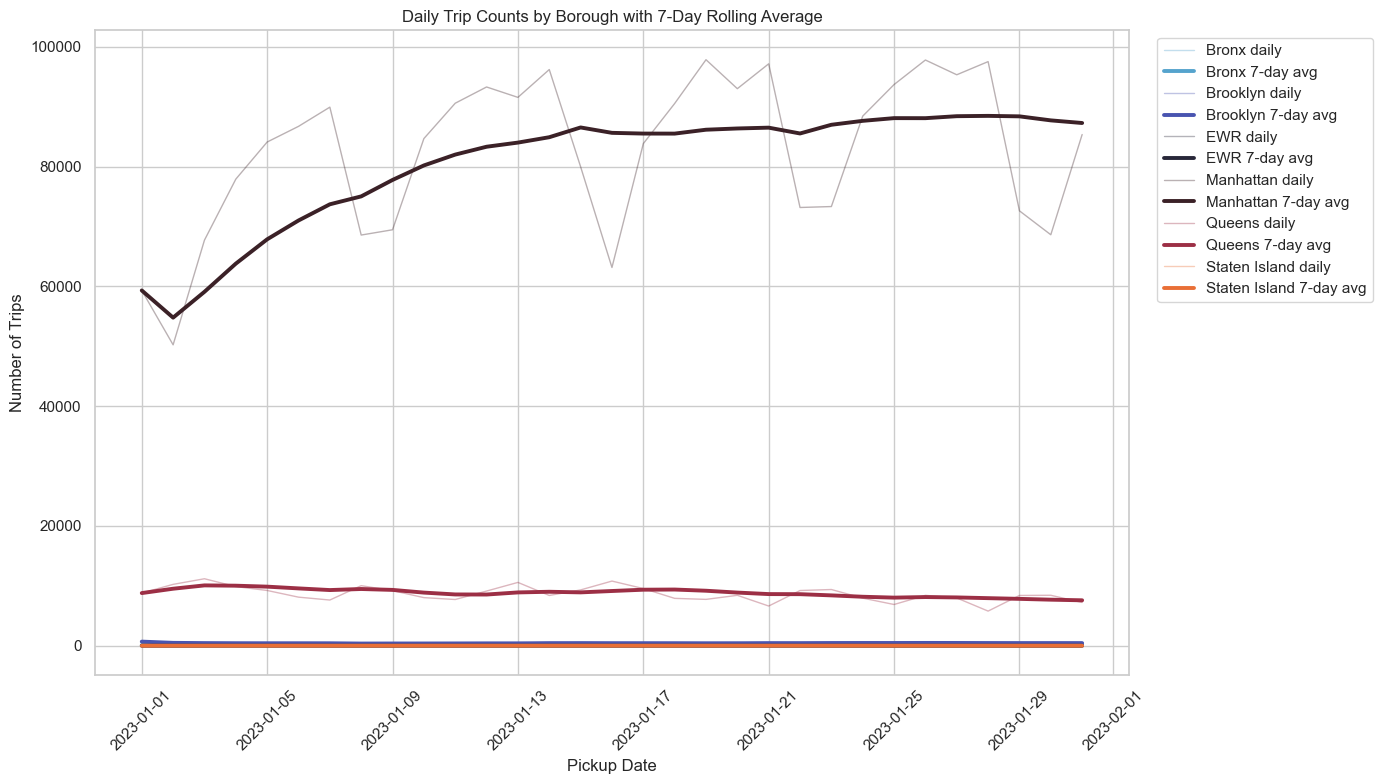

In [34]:
# Define borough list first
boroughs = [b for b in daily_metrics["PU_borough"].dropna().unique() if b != "Unknown"]

# Create Spectral palette
palette = sns.color_palette("icefire", n_colors=len(boroughs))

plt.figure(figsize=(14, 8))

for i, borough in enumerate(sorted(boroughs)):
    
    temp = daily_metrics[daily_metrics["PU_borough"] == borough]

    # Daily trips (lighter)
    plt.plot(
        temp["pickup_date"],
        temp["daily_trip_count"],
        alpha=0.35,
        linewidth=1,
        color=palette[i],
        label=f"{borough} daily"
    )

    # Rolling average (stronger)
    plt.plot(
        temp["pickup_date"],
        temp["rolling_7day_mean"],
        linewidth=2.8,
        color=palette[i],
        label=f"{borough} 7-day avg"
    )

plt.title("Daily Trip Counts by Borough with 7-Day Rolling Average")
plt.xlabel("Pickup Date")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## -> Figure 1.

### Interpretation

Manhattan consistently records the highest number of taxi trips throughout January 2023, with daily volumes typically ranging between roughly 70,000 and 100,000 trips. Thus, this reflects the high concentration of commercial activity, tourism, and transit hubs within the borough.

Brooklyn and Queens show moderate trip volumes when compared with Manhattan, generally remaining below 10,000 daily trips. The Bronx and Staten Island also have substantially lower demand, indicating that yellow taxi usage is much more concentrated within the central areas of the city.

The 7-day rolling average smooths short-term fluctuations in daily demand and highlights the broader trend over the month. The rolling averages indicate relatively stable demand patterns across boroughs, with Manhattan maintaining a consistently high level of taxi activity.

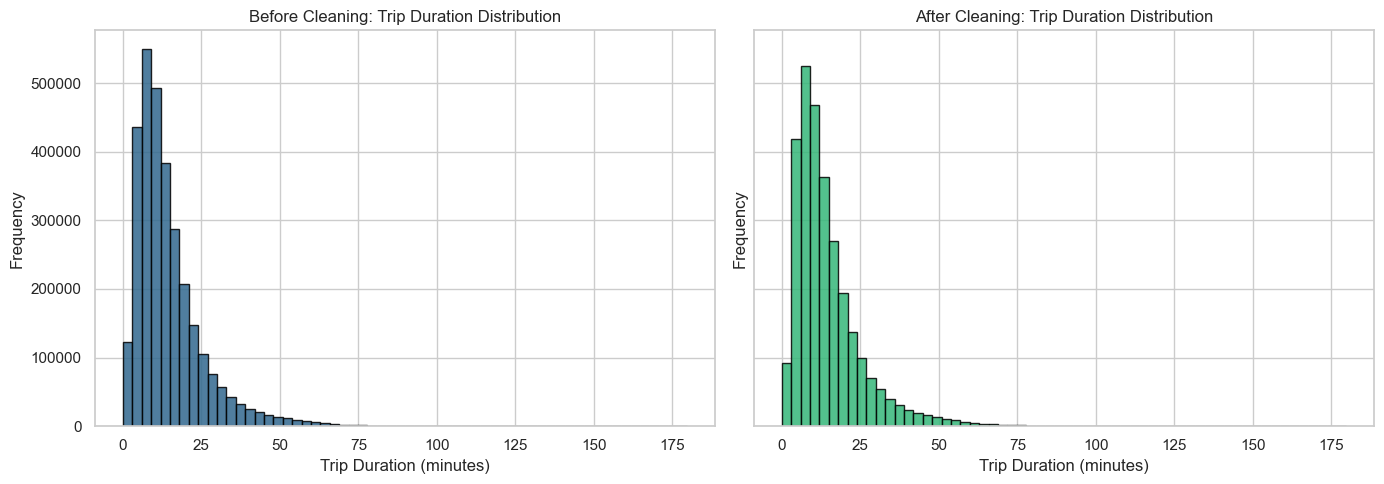

In [29]:
# Compute raw trip duration in minutes from the raw dataset
raw_duration = (
    (pd.to_datetime(raw_df["tpep_dropoff_datetime"]) - pd.to_datetime(raw_df["tpep_pickup_datetime"]))
    .dt.total_seconds() / 60
)

cleaned_duration = df["trip_duration_min"]

# Optional trimming for visibility only
raw_duration_plot = raw_duration[(raw_duration.notna()) & (raw_duration >= 0) & (raw_duration <= 180)]
cleaned_duration_plot = cleaned_duration[(cleaned_duration.notna()) & (cleaned_duration >= 0) & (cleaned_duration <= 180)]

# Use viridis palette
viridis_colors = sns.color_palette("viridis", 2)

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Before cleaning
axes[0].hist(
    raw_duration_plot,
    bins=60,
    color=viridis_colors[0],
    edgecolor="black",
    alpha=0.85
)
axes[0].set_title("Before Cleaning: Trip Duration Distribution")
axes[0].set_xlabel("Trip Duration (minutes)")
axes[0].set_ylabel("Frequency")

# After cleaning
axes[1].hist(
    cleaned_duration_plot,
    bins=60,
    color=viridis_colors[1],
    edgecolor="black",
    alpha=0.85
)
axes[1].set_title("After Cleaning: Trip Duration Distribution")
axes[1].set_xlabel("Trip Duration (minutes)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## -> Figure 2.

### Interpretation

The distribution of trip durations is strongly right-skewed both before and after cleaning, indicating that most taxi trips are relatively short while a small number of trips take significantly longer.

Before cleaning, the distribution includes a wider spread of extreme values, suggesting the presence of outliers; such as unusually long trips or even potential data errors. After cleaning, the distribution becomes more concentrated within a realistic range of trip durations, while still maintaining the overall shape of the distribution.

This suggests that the cleaning process successfully removed unrealistic values while preserving the general characteristics of taxi trip durations in the dataset.

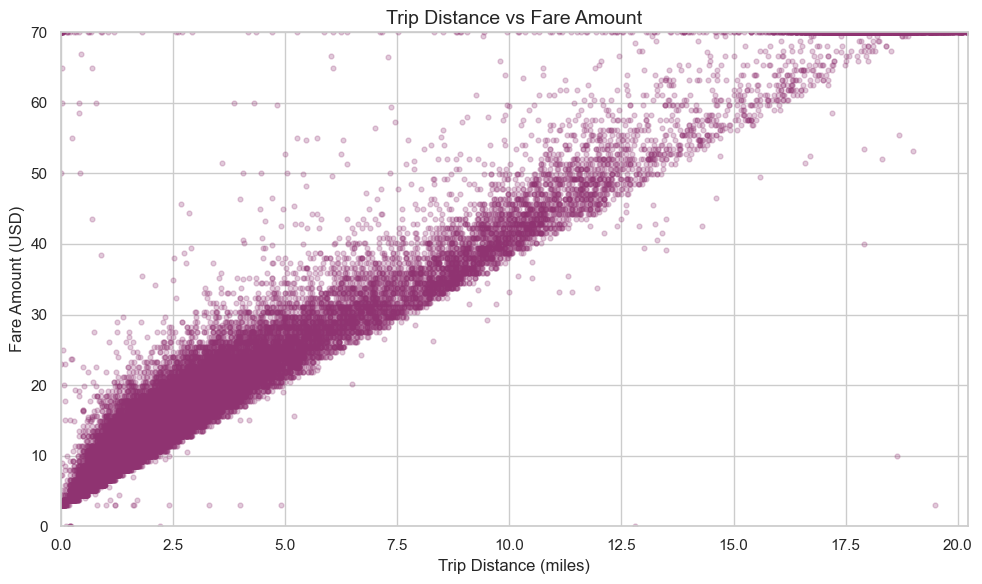

In [ ]:
plot_sample = df[["trip_distance", "fare_amount"]].dropna().sample(
    n=min(50000, len(df)),
    random_state=42
)

mako_palette = sns.color_palette("flare")
scatter_color = mako_palette[4]

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_sample["trip_distance"],
    plot_sample["fare_amount"],
    color=scatter_color,
    alpha=0.25,
    s=12
)

plt.title("Trip Distance vs Fare Amount", fontsize=14)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount (USD)")

plt.xlim(0, plot_sample["trip_distance"].quantile(0.99))
plt.ylim(0, plot_sample["fare_amount"].quantile(0.99))

plt.tight_layout()
plt.show()

## -> Figure 3.

### Interpretation

The scatter plot shows a strong positive relationship between trip distance and fare amount. As trip distance increases, the fare generally increases as well, which is consistent with the distance-based pricing structure used by New York City taxis.

Most trips occur within a relatively short distance range of approximately 0–6 miles, with corresponding fares typically below $30. Longer trips become less frequent but continue to follow the upward trend in fare.

A few outliers appear in the data, where fares are unusually high or low relative to the distance traveled. These may be due to factors such as tolls, surcharges, or perhaps data irregularities. Overall, the plot confirms a clear linear relationship between trip distance and fare amount.

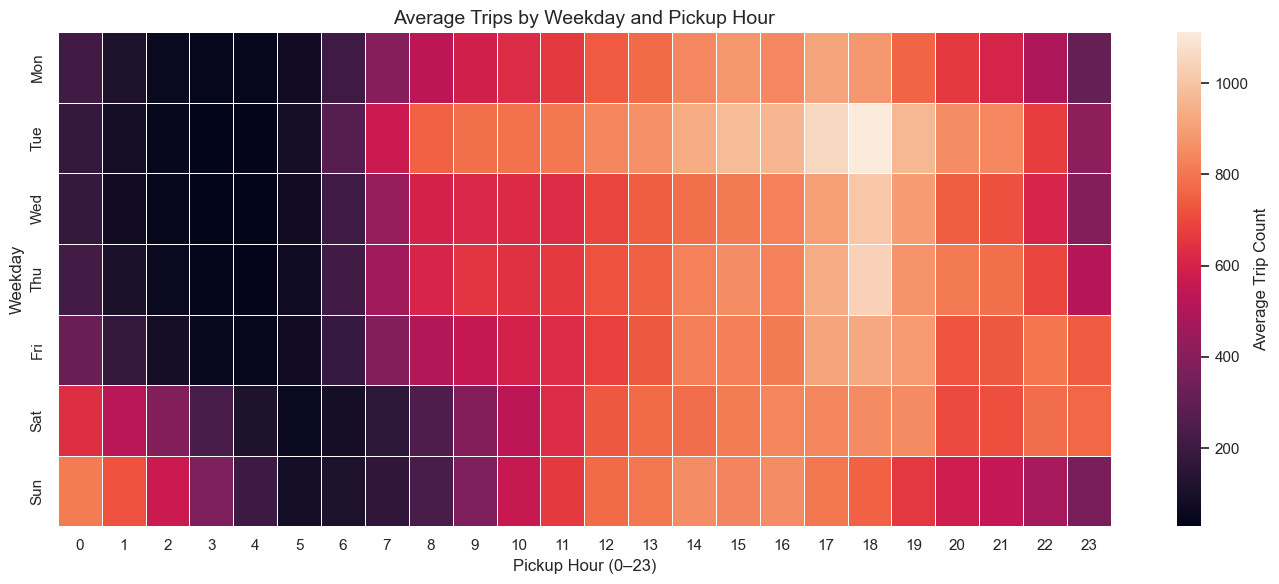

In [31]:
daily_hourly_trips = (
    df.groupby(["pickup_date", "weekday", "pickup_hour"], observed=False)
      .size()
      .reset_index(name="trip_count")
)

avg_weekday_hour_trips = (
    daily_hourly_trips.groupby(["weekday", "pickup_hour"], observed=False)["trip_count"]
                     .mean()
                     .reset_index(name="avg_trip_count")
)

heatmap_data = (
    avg_weekday_hour_trips
    .pivot(index="weekday", columns="pickup_hour", values="avg_trip_count")
    .reindex(weekday_order)
)

rocket_cmap = sns.color_palette("rocket", as_cmap=True)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap=rocket_cmap,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Average Trip Count"}
)

plt.title("Average Trips by Weekday and Pickup Hour", fontsize=14)
plt.xlabel("Pickup Hour (0–23)")
plt.ylabel("Weekday")

plt.tight_layout()
plt.show()

## -> Figure 4.

### Interpretation

The heatmap reveals clear temporal patterns in taxi demand across both weekdays and hours of the day. Trip activity is lowest during the early morning hours between approximately 2:00 AM and 5:00 AM across most days.

Demand increases steadily during the morning commuting period, particularly between 7:00 AM and 10:00 AM, and remains relatively high throughout the afternoon and early evening hours. The highest levels of activity generally occur between midday and the early evening.

Weekend patterns differ slightly from weekdays. Saturdays and Sundays show higher activity during late-night and early-morning hours compared with weekdays, reflecting increased nightlife and leisure travel. Overall, the heatmap highlights strong daily cycles in taxi usage driven by commuting patterns and social activity.

## Summary of Findings

Overall, this notebook computed all required grouped statistics, rolling metrics, anomaly detection results, and visualizations for Part 1.

Key outputs include:
- borough-level daily trip patterns,
- weekday and hourly demand structure,
- payment-type composition by hour,
- tip behavior across distance buckets,
- temporal smoothing through rolling averages,
- anomaly detection using z-scores,
- and a comparison of the strength of association between tip rate and two explanatory variables.
